# Air Quality Analysis - ML Pipeline

This notebook analyzes the UCI Air Quality dataset using Pandas and Scikit-Learn.





# Task #1: Google Cloud Environment Verification
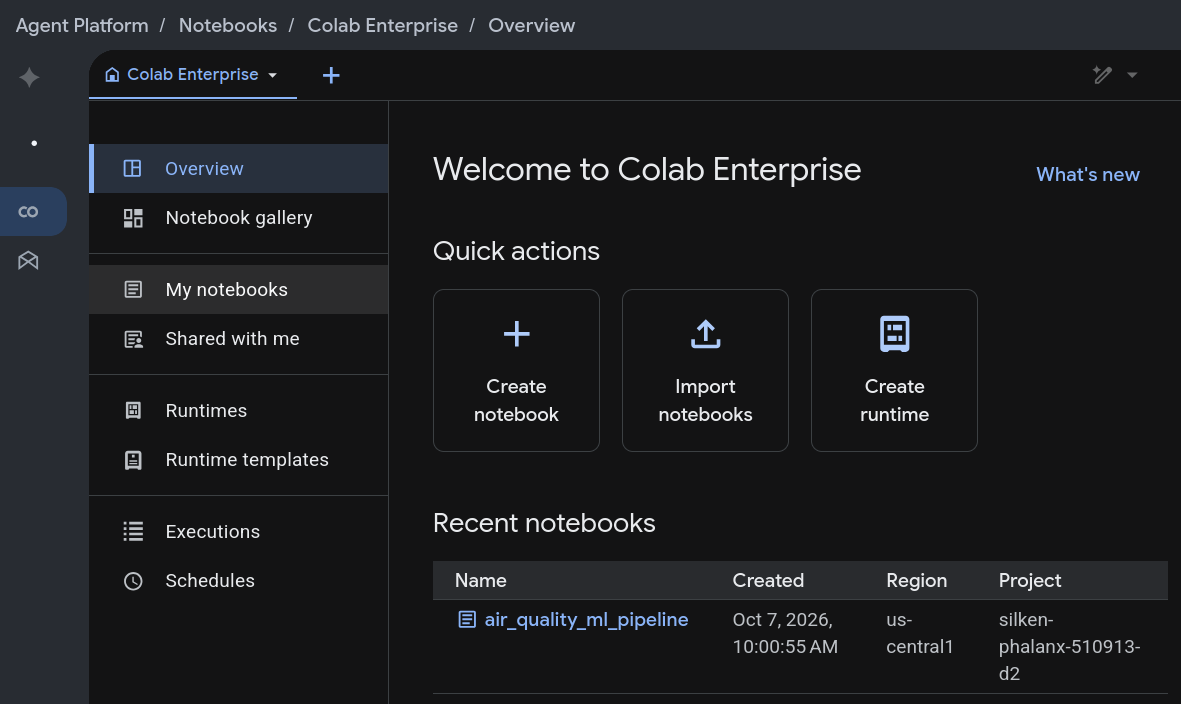




Resource Utilization:

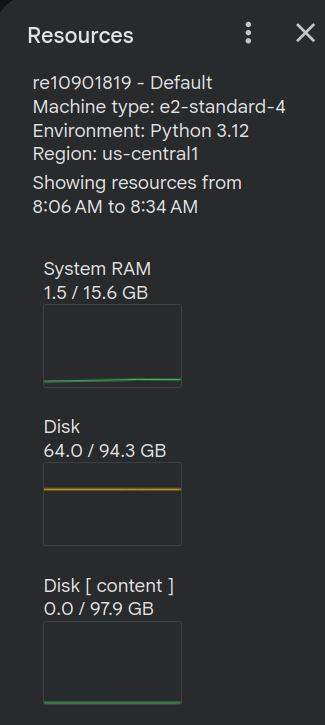

# Task #2: Loading the UCI Air Quality Dataset

The dataset is directly loaded from the UCI repository.

The -200 values are converted to NaN during loading.

In [ ]:
import io
import time
import zipfile
import urllib.request

import numpy as np
import pandas as pd

# Downloads the official UCI dataset
url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"

with urllib.request.urlopen(url) as response:
  zip_data = response.read()

with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
  print("Files in UCI archive:")
  print(z.namelist())

  # Reads the main CSV file from the archive
  with z.open("AirQualityUCI.csv") as f:
    df = pd.read_csv(
        f,
        sep=";",
        decimal=",",
        na_values=[-200],
    )

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

Files in UCI archive:
['AirQualityUCI.csv', 'AirQualityUCI.xlsx']

Dataset loaded successfully.
Shape: (9471, 17)


# Task #3: Structural inspection of the data

Uses head(), info(), and describe() to examine the dataset structure, variables, datatypes, and feature distributions.

In [ ]:
print("\n------ Head -----\n")
print(df.head())

print("\n------ Info -----\n")
print(df.info())

print("\n------ Describe -----\n")
print(df.describe())

print("\n------ Missing Values ------")
print(df.isna().sum())


------ Head -----

         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  Unnamed: 15  Unnamed: 16  
0  13.6  48.9  0.7578          NaN          Na

# Task #4: Handling missing data

The UCI Air Quality dataset uses -200 as an implicit missing value marker.

The value is converted to NaN during loading.

Missing numerical features will be handled using median imputation using the SimpleImputer.

The rows with missing CO(GT) target values are removed here because the target itself should not be artificially imputed for supervised learning.

In [ ]:
# Removes the empty/unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Removes the rows without a valid date
df = df.dropna(subset=["Date"]).copy()

# Converts Date into a real datetime value
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

cleaned_time = df["Time"].astype(str).str.strip()

# Parses the time and creates temporal features
time_parsed = pd.to_datetime(
    cleaned_time,
    format="%H.%M.%S",
    errors="coerce",
)

df["Hour"] = time_parsed.dt.hour
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month

# Creates a categorical time-period feature
df["TimeOfDay"] = pd.cut(
    df["Hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"],
)

print("\nMissing values after converting -200 to NaN:")
print(df.isna().sum())

# Keeps only rows with an actual regression target
regression_df = df.dropna(subset=["CO(GT)"]).copy()

print("\nRows available for supervised learning:", len(regression_df))


Missing values after converting -200 to NaN:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Hour                0
DayOfWeek           0
Month               0
TimeOfDay           0
dtype: int64

Rows available for supervised learning: 7674


# Task #5: Numeric and Categoric Feature Preprocessing

Numeric variables use median imputation followed by StandardScaler.

Categoric/Temporal variables use the most frequent imputation followed by OneHotEncoder.

The ColumnTransformer combines the two preprocessing strategies.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# The features used to predict CO(GT)
feature_columns = [
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
    "Hour",
    "DayOfWeek",
    "Month",
    "TimeOfDay",
]

X = regression_df[feature_columns]
y_reg = regression_df["CO(GT)"]

numeric_cols = [
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
    "Hour",
    "DayOfWeek",
    "Month",
]

categoric_cols = [
    "TimeOfDay"
]

numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categoric_cols),
    ]
)

print("Numeric features:", numeric_cols)
print("Categoric features:", categoric_cols)


Numeric features: ['PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'DayOfWeek', 'Month']
Categoric features: ['TimeOfDay']


**Task #6: Classification Target Binning**

CO(GT) is a continuous value, so it needs to be converted into categoric classes before classification.

Quantile binning creates three approximately balanced classes:

*   Class 0 = Low
*   Class 1 = Moderate
*   Class 2 = High


In [ ]:
from sklearn.linear_model import (
    Lasso,
    LinearRegression,
    LogisticRegression,
    Ridge,
    SGDClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

y_class = pd.qcut(
    regression_df["CO(GT)"],
    q=3,
    labels=[0, 1, 2],
)

print("\nClassification class distribution:")
print(y_class.value_counts().sort_index())

print("\nClassification thresholds:")
print(
    pd.qcut(
        regression_df["CO(GT)"],
        q=3
    ).describe()
)




Classification class distribution:
CO(GT)
0    2623
1    2506
2    2545
Name: count, dtype: int64

Classification thresholds:
count             7674
unique               3
top       (0.099, 1.3]
freq              2623
Name: CO(GT), dtype: object


**Task #6A: Train/Test Split for Classification**

The classification data is split into training and testing sets.

Stratification preserves the class distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training samples: ", len(X_train))
print("Testing samples: ", len(X_test))

Training samples:  6139
Testing samples:  1535


**Task #6B: Logistic/Softmax Regression**

Multinomial logistic regression is used as the baseline classification model.

Training time and classification performance are recorded.

In [ ]:
logistic_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        ),
    ]
)

start_time = time.perf_counter()

logistic_model.fit(X_train, y_train)

logistic_time = time.perf_counter() - start_time

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("\n ------ Logistic Regression ------")
print(f"Training time: {logistic_time:.4f} seconds")
print(f"Accuracy: {logistic_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))



 ------ Logistic Regression ------
Training time: 0.1865 seconds
Accuracy: 0.8769

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       525
           1       0.81      0.82      0.82       501
           2       0.92      0.90      0.91       509

    accuracy                           0.88      1535
   macro avg       0.88      0.88      0.88      1535
weighted avg       0.88      0.88      0.88      1535



**Task #6C: SGDClassifier**

SGDClassifier is configured with logistic loss, L2 regularization, an adaptive learning rate, and explicit convergence parameters.

The training time and the classification performance are compared with logistic regression.

In [ ]:
sgd_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        (
            "classifier",
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                learning_rate="adaptive",
                eta0=0.01,
                max_iter=1000,
                tol=1e-3,
                random_state=42
            )
        ),
    ]
)

start_time = time.perf_counter()

sgd_model.fit(X_train, y_train)

sgd_time = time.perf_counter() - start_time

sgd_predictions = sgd_model.predict(X_test)

sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print("\n ------ SGD Classifier ------")
print(f"Training time: {sgd_time:.4f} seconds")
print(f"Accuracy: {sgd_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, sgd_predictions))


 ------ SGD Classifier ------
Training time: 0.2227 seconds
Accuracy: 0.8775

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       525
           1       0.82      0.82      0.82       501
           2       0.92      0.91      0.92       509

    accuracy                           0.88      1535
   macro avg       0.88      0.88      0.88      1535
weighted avg       0.88      0.88      0.88      1535



**Task #6D: Classification Model Comparison**

Compares the convergence/training speed and predictive performance between Logistic Regression and SGDClassifier.

In [ ]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SGDClassifier"
    ],
    "Training Time (seconds)": [
        logistic_time,
        sgd_time
    ],
    "Accuracy": [
        logistic_accuracy,
        sgd_accuracy
    ]
})

print(classification_comparison)

                 Model  Training Time (seconds)  Accuracy
0  Logistic Regression                 0.186511  0.876873
1        SGDClassifier                 0.222660  0.877524


**Task #7: Regression Models**

The continuous CO(GT) concentration is predicted using:
>1. Linear Regression
>2. Ridge Regression (L2)
>3. Lasso Regression (L1)

Mean Squared Error and R^2 are used for evaluation.

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1, max_iter=10000),
}

regression_results = []

for name, model in regression_models.items():
  reg_pipeline = Pipeline(
      steps = [
          ("preprocessor", preprocessor),
          ("regressor", model)
      ]
  )

  start_time = time.perf_counter()

  reg_pipeline.fit(X_train_r, y_train_r)

  training_time = time.perf_counter() - start_time

  predictions = reg_pipeline.predict(X_test_r)

  mse = mean_squared_error(y_test_r, predictions)

  r2 = r2_score(y_test_r, predictions)

  regression_results.append({
      "Model": name,
      "MSE": mse,
      "R2": r2,
      "Training Time": training_time
  })

  print(f"------ {name} ------")
  print(f"MSE: {mse:.4f}")
  print(f"R2: {r2:.4f}")
  print(f"Training time: {training_time:.4f} seconds")


------ Linear Regression ------
MSE: 0.2018
R2: 0.9031
Training time: 0.0480 seconds
------ Ridge (L2) ------
MSE: 0.2018
R2: 0.9031
Training time: 0.0480 seconds
------ Lasso (L1) ------
MSE: 0.2764
R2: 0.8673
Training time: 0.0453 seconds


**Task #7A: Regression Model Comparison**



In [ ]:
regression_results_df = pd.DataFrame(regression_results)

print(f"\nRegression Model Comparisson:")
print(regression_results_df)


Regression Model Comparisson:
               Model       MSE        R2  Training Time
0  Linear Regression  0.201812  0.903109       0.048043
1         Ridge (L2)  0.201815  0.903108       0.047996
2         Lasso (L1)  0.276376  0.867310       0.045256


**Task #7B: Ridge Regularization Analysis**

Ridge regression uses L2 regularization.

The alpha parameter controls the strength of the regularization.

Larger alpha values should generally shrink the coefficients more strongly.

In [ ]:
ridge_alphas = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

ridge_results = []

for alpha in ridge_alphas:
  ridge_pipeline = Pipeline(
      steps = [
          ("preprocessor", preprocessor),
          ("regressor", Ridge(alpha=alpha))
      ]
  )

  ridge_pipeline.fit(X_train_r, y_train_r)

  predictions = ridge_pipeline.predict(X_test_r)

  coefficients = ridge_pipeline.named_steps["regressor"].coef_

  ridge_results.append({
        "alpha": alpha,
        "MSE": mean_squared_error(y_test_r, predictions),
        "R2": r2_score(y_test_r, predictions),
        "Coefficient L1 Sum": np.sum(np.abs(coefficients)),
        "Coefficient L2 Norm": np.linalg.norm(coefficients)
  })

ridge_results_df = pd.DataFrame(ridge_results)

print("\n------ Ridge Alpha Analysis ------")
print(ridge_results_df)



------ Ridge Alpha Analysis ------
     alpha       MSE        R2  Coefficient L1 Sum  Coefficient L2 Norm
0    0.001  0.201812  0.903109            4.244130             1.265806
1    0.010  0.201812  0.903109            4.243828             1.265720
2    0.100  0.201812  0.903109            4.240810             1.264865
3    1.000  0.201815  0.903108            4.211123             1.256495
4   10.000  0.201949  0.903043            3.955159             1.187636
5  100.000  0.205157  0.901503            2.991114             0.950477


**Task #7C: Lasso Regularization and Feature Selection**

Lasso uses L1 regularization.

Increasing alpha increases the penalty and can force coefficients to exactly zero, effectively performing feature selection.

In [ ]:
lasso_alphas = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0
]

lasso_results = []

for alpha in lasso_alphas:

    lasso_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", Lasso(alpha=alpha, max_iter=10000))
        ]
    )

    lasso_pipeline.fit(X_train_r, y_train_r)

    predictions = lasso_pipeline.predict(X_test_r)

    coefficients = lasso_pipeline.named_steps["regressor"].coef_

    nonzero_coefficients = np.sum(
        np.abs(coefficients) > 1e-6
    )

    lasso_results.append({
        "alpha": alpha,
        "MSE": mean_squared_error(y_test_r, predictions),
        "R2": r2_score(y_test_r, predictions),
        "Non-zero Coefficients": nonzero_coefficients,
        "Total Coefficients": len(coefficients)
    })

lasso_results_df = pd.DataFrame(lasso_results)

print("\n------ Lasso Alpha Analysis ------")
print(lasso_results_df)




------ Lasso Alpha Analysis ------
    alpha       MSE        R2  Non-zero Coefficients  Total Coefficients
0   0.001  0.202224  0.902911                     17                  19
1   0.010  0.210885  0.898753                     16                  19
2   0.100  0.276376  0.867310                      6                  19
3   1.000  1.411864  0.322157                      1                  19
4  10.000  2.087465 -0.002202                      0                  19


**Task #7D: Lasso Feature Selection**

Displays the features retained by a representative Lasso model.

Features whose coefficients are exactly/approximately zero are considered eliminated by L1 regularization.

In [ ]:
# Fits a Lasso Model
final_lasso = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("regressor", Lasso(alpha=0.1, max_iter=10000))
    ]
)

final_lasso.fit(X_train_r, y_train_r)

# Gets the transformed feature names
feature_names = final_lasso.named_steps[
    "preprocessor"
].get_feature_names_out()

lasso_coefficients = final_lasso.named_steps[
    "regressor"
].coef_

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coefficients,
    "Absolute Coefficient": np.abs(lasso_coefficients)
})

coefficient_table = coefficient_table.sort_values(
    "Absolute Coefficient",
    ascending=False
)

print("\n ------ Lasso Feature Coefficients ------")
print(coefficient_table)

print("\nSelected/non-zero features:")
print(
    coefficient_table[
        coefficient_table["Absolute Coefficient"] > 1e-6
    ][
        ["Feature", "Coefficient"]
    ]
)


 ------ Lasso Feature Coefficients ------
                     Feature  Coefficient  Absolute Coefficient
2              num__C6H6(GT)     0.757678              0.757678
4               num__NOx(GT)     0.375778              0.375778
0           num__PT08.S1(CO)     0.183213              0.183213
6               num__NO2(GT)     0.042967              0.042967
12                 num__Hour     0.021455              0.021455
1              num__NMHC(GT)     0.009542              0.009542
3         num__PT08.S2(NMHC)     0.000000              0.000000
7          num__PT08.S4(NO2)     0.000000              0.000000
8           num__PT08.S5(O3)     0.000000              0.000000
9                     num__T    -0.000000              0.000000
5          num__PT08.S3(NOx)    -0.000000              0.000000
10                   num__RH    -0.000000              0.000000
11                   num__AH    -0.000000              0.000000
13            num__DayOfWeek    -0.000000              0.0000

**Task #8: Google Cloud Billing**

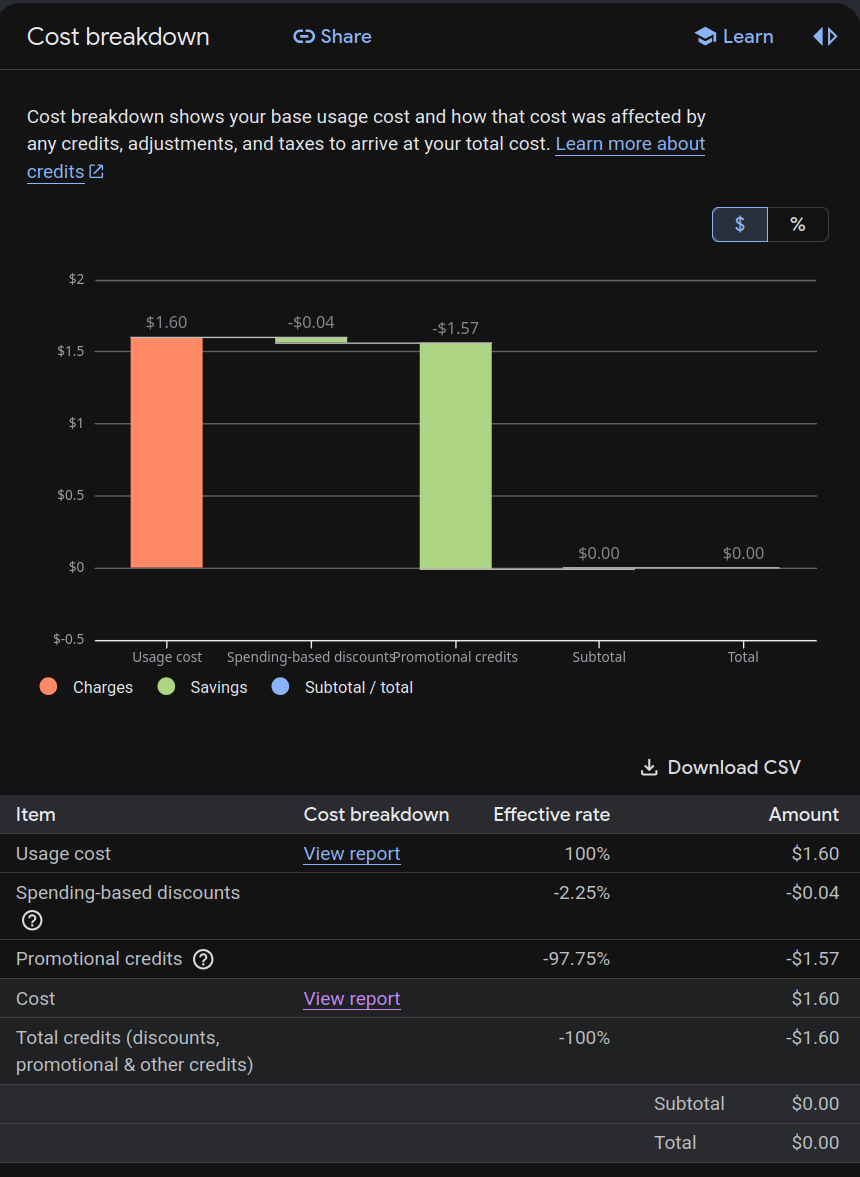